In [83]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from plot_utilities import (
    setup_notebook_display,
    plot_strategy_radar_charts,
    plot_bar_chart
)

setup_notebook_display(figsize=(10, 6))

df = pd.read_csv('../performance/player_strength_panel.csv')
print(f'Loaded {len(df)} rows, {df["player_type"].nunique()} player types, {df["game_id"].nunique()} games')
df.head()

Loaded 2248 rows, 15 player types, 280 games


,game_id,player_id,player_type,civilization,experiment,weighted_strength,is_winner,max_weighted_strength,relative_strength,adjusted_strength,turn,map_type,map_size,difficulty,game_speed,victory_type,victory_player_id,score,score_rank,score_ratio,survival_turn,input_tokens,reasoning_tokens,output_tokens,strategy_changes,persona_changes,research_changes,policy_changes,nuke,use_nuke,domination_ratio,culture_ratio,diplomatic_ratio,science_ratio,tradition,authority,progress,fealty,statecraft,artistry,industry,imperialism,rationalism,freedom,autocracy,order,condition,strategy_change_rate,persona_change_rate
0,00a56d80-647b-405d-be7f-8e3ab71315ae,0,Vanilla,Persia,2026-oss-v-glm-standard,0.014368,0,0.701126,0.020493,0.167177,500,Vox_Deorum,Standard,Prince,Standard,Time,5,2521,4,0.5304,499,0.0,0.0,0.0,266,1,0,0,50.0,50.0,0.2605,0.1403,0.0401,0.5591,NaN,21.0,NaN,NaN,NaN,170.0,NaN,296.0,NaN,379.0,NaN,NaN,2026-oss-v-glm-standard,0.533066,0.002004
1,00a56d80-647b-405d-be7f-8e3ab71315ae,1,Vanilla,The Huns,2026-oss-v-glm-standard,0.009419,0,0.701126,0.013434,0.081890,500,Vox_Deorum,Standard,Prince,Standard,Time,5,1806,7,0.3800,499,0.0,0.0,0.0,242,1,0,0,50.0,50.0,0.4600,0.0000,0.0000,0.5400,NaN,15.0,NaN,164.0,NaN,NaN,NaN,295.0,NaN,NaN,453.0,398.0,2026-oss-v-glm-standard,0.484970,0.002004
2,00a56d80-647b-405d-be7f-8e3ab71315ae,2,Vanilla,Ethiopia,2026-oss-v-glm-standard,0.032256,0,0.701126,0.046006,0.114262,500,Vox_Deorum,Standard,Prince,Standard,Time,5,1911,5,0.4021,499,0.0,0.0,0.0,235,1,0,0,50.0,50.0,0.0000,0.1600,0.0000,0.8400,NaN,NaN,12.0,NaN,NaN,120.0,NaN,NaN,285.0,NaN,362.0,NaN,2026-oss-v-glm-standard,0.470942,0.002004
3,00a56d80-647b-405d-be7f-8e3ab71315ae,3,Vanilla,Mongolia,2026-oss-v-glm-standard,0.098679,0,0.701126,0.140743,0.335146,500,Vox_Deorum,Standard,Prince,Standard,Time,5,3327,2,0.7000,499,0.0,0.0,0.0,254,1,0,0,50.0,50.0,0.5600,0.0000,0.0000,0.4400,NaN,18.0,NaN,162.0,NaN,NaN,NaN,256.0,NaN,NaN,NaN,347.0,2026-oss-v-glm-standard,0.509018,0.002004
4,00a56d80-647b-405d-be7f-8e3ab71315ae,4,GPT-OSS-120B-Simple,England,2026-oss-v-glm-standard,0.121765,0,0.701126,0.173671,0.289580,500,Vox_Deorum,Standard,Prince,Standard,Time,5,3213,3,0.6760,499,23862480.0,592382.0,127026.0,200,66,67,91,40.0,40.0,0.0000,0.0020,0.0000,0.9980,22.0,64.0,20.0,185.0,146.0,198.0,273.0,316.0,252.0,NaN,355.0,NaN,2026-oss-v-glm-standard,0.400802,0.132265


## Ideology Choice and Nuclear Weapon Preferences

C:\Users\John Chen\AppData\Local\Temp\ipykernel_252512\4054624801.py:5: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin(axis=1)


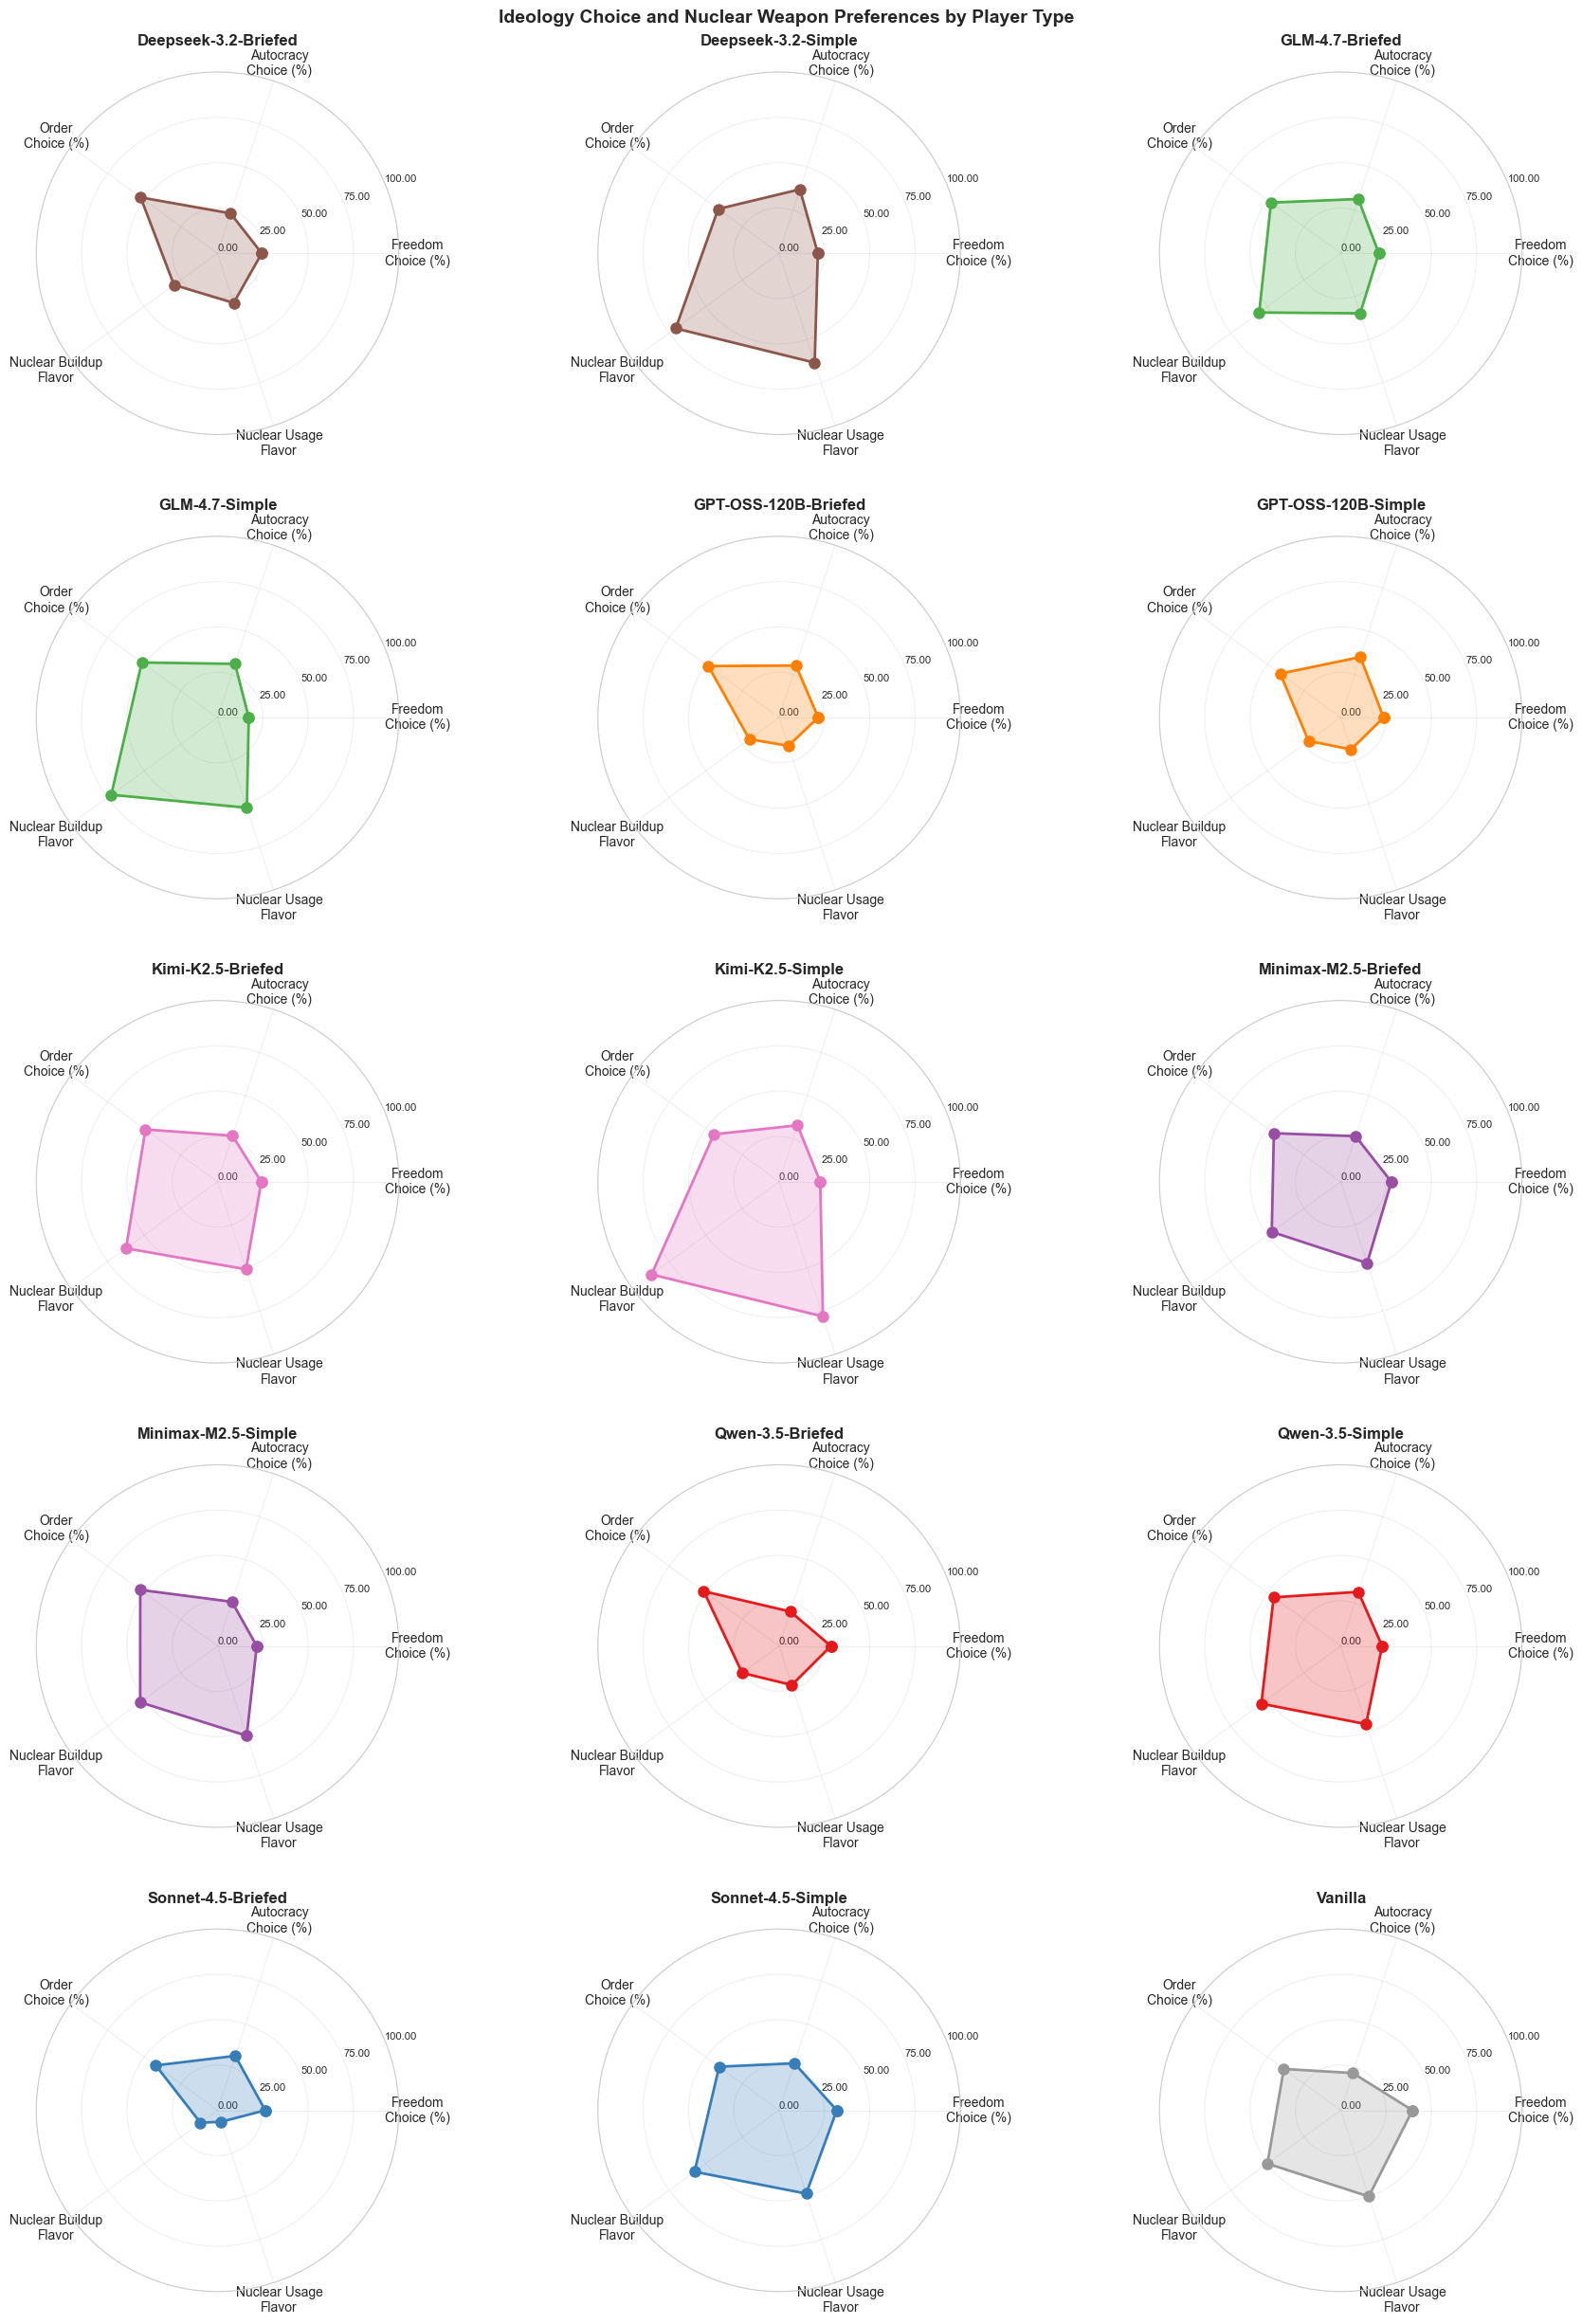


Ideology Choice and Nuclear Weapon Preferences by Player Type Summary:


c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,N,Freedom Choice (%),Autocracy Choice (%),Order Choice (%),Nuclear Buildup Flavor,Nuclear Usage Flavor
Deepseek-3.2-Briefed,116,"24.390 [14.896, 33.884]","23.171 [13.843, 32.498]","52.439 [41.398, 63.480]","29.697 [19.997, 39.397]","28.788 [19.302, 38.274]"
Deepseek-3.2-Simple,116,"21.348 [12.668, 30.029]","37.079 [26.846, 47.311]","41.573 [31.132, 52.014]","70.513 [58.092, 82.934]","63.462 [50.510, 76.413]"
GLM-4.7-Briefed,180,"20.979 [14.225, 27.733]","31.469 [23.765, 39.172]","47.552 [39.268, 55.837]","55.609 [48.393, 62.824]","34.826 [28.684, 40.968]"
GLM-4.7-Simple,180,"17.219 [11.128, 23.309]","31.126 [23.656, 38.596]","51.656 [43.593, 59.718]","72.473 [66.340, 78.606]","52.333 [46.536, 58.130]"
GPT-OSS-120B-Briefed,153,"21.552 [13.957, 29.147]","30.172 [21.694, 38.651]","48.276 [39.046, 57.506]","20.317 [15.986, 24.649]","16.429 [12.765, 20.092]"
GPT-OSS-120B-Simple,153,"23.684 [15.761, 31.608]","35.088 [26.193, 43.982]","41.228 [32.054, 50.402]","21.940 [15.861, 28.020]","18.507 [13.272, 23.742]"
Kimi-K2.5-Briefed,144,"24.138 [16.234, 32.042]","26.724 [18.550, 34.898]","49.138 [39.904, 58.372]","62.431 [55.081, 69.780]","50.764 [44.020, 57.508]"
Kimi-K2.5-Simple,144,"22.689 [15.054, 30.324]","32.773 [24.216, 41.330]","44.538 [35.477, 53.598]","86.985 [81.609, 92.362]","78.132 [71.001, 85.264]"
Minimax-M2.5-Briefed,91,"27.941 [16.999, 38.883]","26.471 [15.712, 37.229]","45.588 [33.443, 57.733]","47.027 [43.997, 50.057]","47.162 [43.423, 50.901]"
Minimax-M2.5-Simple,91,"21.622 [12.019, 31.224]","25.676 [15.486, 35.866]","52.703 [41.057, 64.349]","52.778 [48.588, 56.968]","52.037 [47.505, 56.569]"


(<Figure size 1800x2500 with 15 Axes>,
 array([<PolarAxes: title={'center': 'Deepseek-3.2-Briefed'}>,
        <PolarAxes: title={'center': 'Deepseek-3.2-Simple'}>,
        <PolarAxes: title={'center': 'GLM-4.7-Briefed'}>,
        <PolarAxes: title={'center': 'GLM-4.7-Simple'}>,
        <PolarAxes: title={'center': 'GPT-OSS-120B-Briefed'}>,
        <PolarAxes: title={'center': 'GPT-OSS-120B-Simple'}>,
        <PolarAxes: title={'center': 'Kimi-K2.5-Briefed'}>,
        <PolarAxes: title={'center': 'Kimi-K2.5-Simple'}>,
        <PolarAxes: title={'center': 'Minimax-M2.5-Briefed'}>,
        <PolarAxes: title={'center': 'Minimax-M2.5-Simple'}>,
        <PolarAxes: title={'center': 'Qwen-3.5-Briefed'}>,
        <PolarAxes: title={'center': 'Qwen-3.5-Simple'}>,
        <PolarAxes: title={'center': 'Sonnet-4.5-Briefed'}>,
        <PolarAxes: title={'center': 'Sonnet-4.5-Simple'}>,
        <PolarAxes: title={'center': 'Vanilla'}>], dtype=object))

In [84]:
# Compute ideology choice from earliest adoption turn
ideology_cols = ['freedom', 'autocracy', 'order']
df['ideology_choice'] = (
    df[ideology_cols]
    .idxmin(axis=1)
    .where(df[ideology_cols].notna().any(axis=1), None)
    .str.title()
)

ideology_mask = df['ideology_choice'].notna()
df.loc[ideology_mask, 'freedom_pct'] = (df.loc[ideology_mask, 'ideology_choice'] == 'Freedom').astype(float) * 100
df.loc[ideology_mask, 'autocracy_pct'] = (df.loc[ideology_mask, 'ideology_choice'] == 'Autocracy').astype(float) * 100
df.loc[ideology_mask, 'order_pct'] = (df.loc[ideology_mask, 'ideology_choice'] == 'Order').astype(float) * 100

plot_strategy_radar_charts(
    df,
    columns=['freedom_pct', 'autocracy_pct', 'order_pct', 'nuke', 'use_nuke'],
    labels=['Freedom\nChoice (%)', 'Autocracy\nChoice (%)', 'Order\nChoice (%)',
            'Nuclear Buildup\nFlavor', 'Nuclear Usage\nFlavor'],
    title='Ideology Choice and Nuclear Weapon Preferences by Player Type',
    ylim=(0, 100),
    print_summary=True
)

## Grand Strategy Profiles and Adaptability

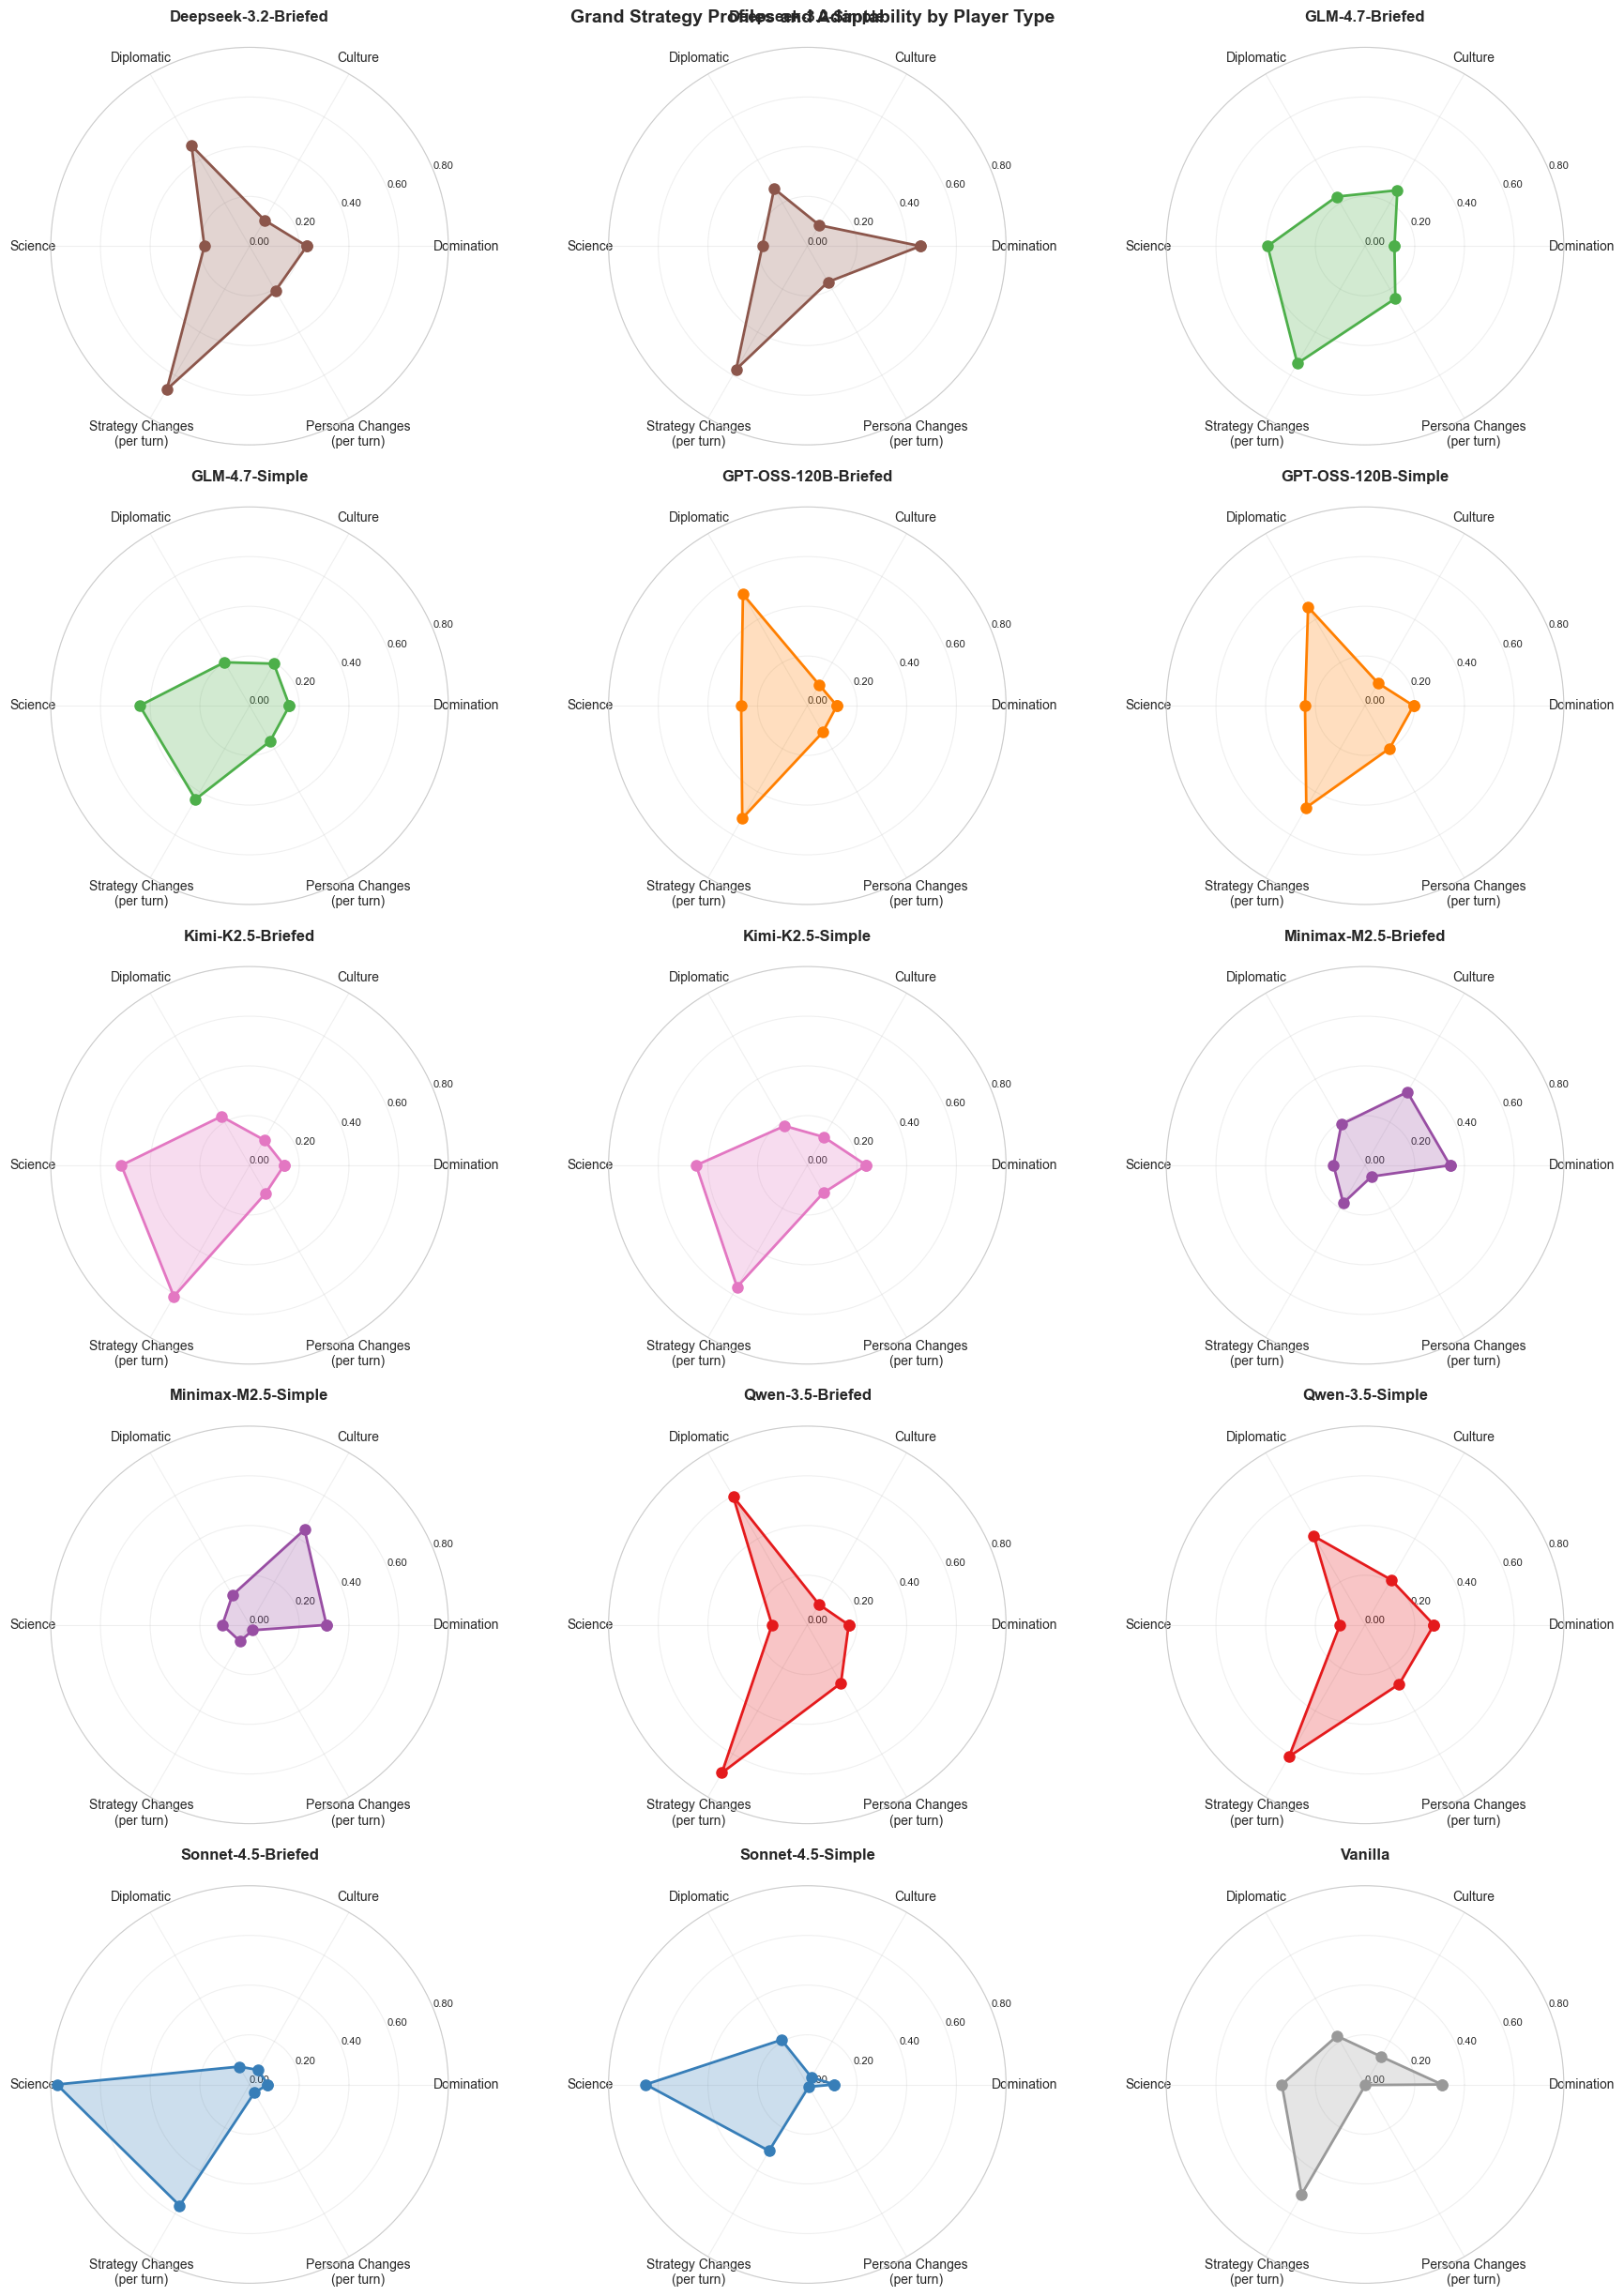


Grand Strategy Profiles and Adaptability by Player Type Summary:


,N,Domination,Culture,Diplomatic,Science,Strategy Changes (per turn),Persona Changes (per turn)
Deepseek-3.2-Briefed,116,"0.231 [0.173, 0.289]","0.121 [0.069, 0.173]","0.467 [0.407, 0.526]","0.182 [0.135, 0.229]","0.666 [0.651, 0.680]","0.208 [0.192, 0.223]"
Deepseek-3.2-Simple,116,"0.455 [0.384, 0.526]","0.097 [0.053, 0.141]","0.267 [0.203, 0.331]","0.181 [0.137, 0.225]","0.572 [0.555, 0.590]","0.167 [0.156, 0.177]"
GLM-4.7-Briefed,180,"0.118 [0.083, 0.153]","0.260 [0.206, 0.313]","0.230 [0.178, 0.282]","0.392 [0.334, 0.451]","0.545 [0.535, 0.556]","0.244 [0.231, 0.256]"
GLM-4.7-Simple,180,"0.160 [0.119, 0.202]","0.195 [0.147, 0.243]","0.202 [0.152, 0.251]","0.442 [0.382, 0.503]","0.435 [0.425, 0.445]","0.165 [0.156, 0.174]"
GPT-OSS-120B-Briefed,153,"0.119 [0.093, 0.145]","0.097 [0.064, 0.130]","0.518 [0.473, 0.563]","0.266 [0.212, 0.320]","0.524 [0.510, 0.537]","0.124 [0.112, 0.136]"
GPT-OSS-120B-Simple,153,"0.195 [0.155, 0.235]","0.105 [0.067, 0.142]","0.459 [0.412, 0.505]","0.242 [0.185, 0.299]","0.473 [0.460, 0.486]","0.198 [0.184, 0.213]"
Kimi-K2.5-Briefed,144,"0.139 [0.102, 0.176]","0.118 [0.081, 0.154]","0.227 [0.179, 0.275]","0.516 [0.461, 0.571]","0.609 [0.591, 0.628]","0.130 [0.117, 0.142]"
Kimi-K2.5-Simple,144,"0.238 [0.187, 0.288]","0.132 [0.089, 0.175]","0.183 [0.138, 0.228]","0.448 [0.396, 0.500]","0.565 [0.546, 0.585]","0.129 [0.117, 0.140]"
Minimax-M2.5-Briefed,91,"0.342 [0.245, 0.439]","0.340 [0.246, 0.435]","0.191 [0.112, 0.269]","0.127 [0.059, 0.195]","0.176 [0.165, 0.186]","0.052 [0.048, 0.057]"
Minimax-M2.5-Simple,91,"0.309 [0.215, 0.404]","0.443 [0.342, 0.544]","0.138 [0.068, 0.208]","0.109 [0.046, 0.172]","0.076 [0.071, 0.082]","0.025 [0.022, 0.028]"


(<Figure size 1800x2500 with 15 Axes>,
 array([<PolarAxes: title={'center': 'Deepseek-3.2-Briefed'}>,
        <PolarAxes: title={'center': 'Deepseek-3.2-Simple'}>,
        <PolarAxes: title={'center': 'GLM-4.7-Briefed'}>,
        <PolarAxes: title={'center': 'GLM-4.7-Simple'}>,
        <PolarAxes: title={'center': 'GPT-OSS-120B-Briefed'}>,
        <PolarAxes: title={'center': 'GPT-OSS-120B-Simple'}>,
        <PolarAxes: title={'center': 'Kimi-K2.5-Briefed'}>,
        <PolarAxes: title={'center': 'Kimi-K2.5-Simple'}>,
        <PolarAxes: title={'center': 'Minimax-M2.5-Briefed'}>,
        <PolarAxes: title={'center': 'Minimax-M2.5-Simple'}>,
        <PolarAxes: title={'center': 'Qwen-3.5-Briefed'}>,
        <PolarAxes: title={'center': 'Qwen-3.5-Simple'}>,
        <PolarAxes: title={'center': 'Sonnet-4.5-Briefed'}>,
        <PolarAxes: title={'center': 'Sonnet-4.5-Simple'}>,
        <PolarAxes: title={'center': 'Vanilla'}>], dtype=object))

In [85]:
plot_strategy_radar_charts(
    df,
    columns=['domination_ratio', 'culture_ratio', 'diplomatic_ratio',
             'science_ratio', 'strategy_change_rate', 'persona_change_rate'],
    labels=['Domination', 'Culture', 'Diplomatic', 'Science',
            'Strategy Changes\n(per turn)', 'Persona Changes\n(per turn)'],
    title='Grand Strategy Profiles and Adaptability by Player Type',
    print_summary=True,
    ylim=(0, 0.8)
)

## Civ-Adjusted Relative Strength by Player Type

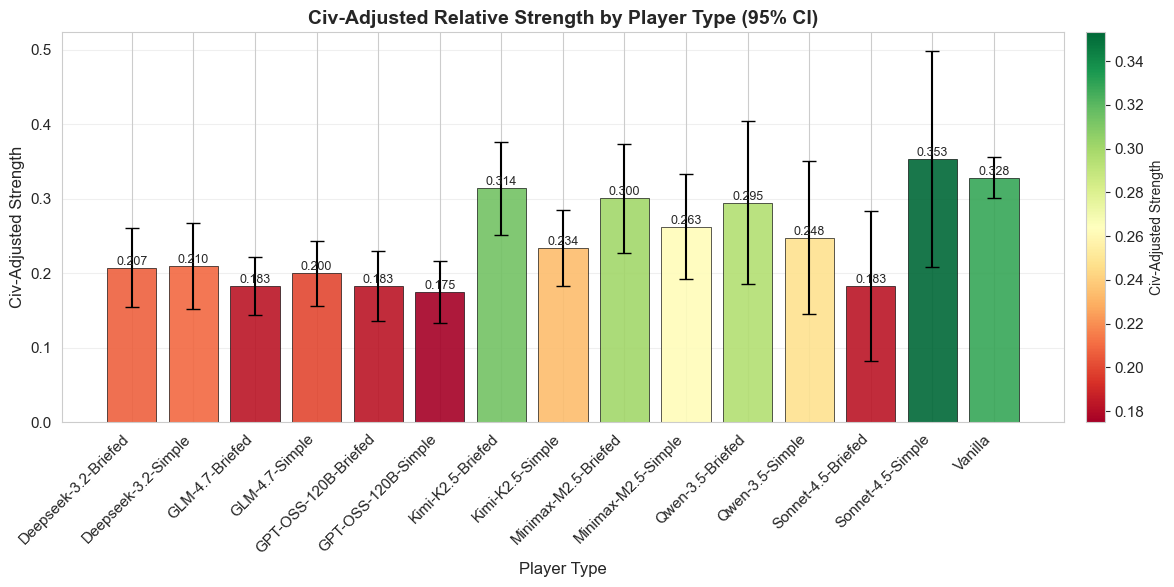

,Mean,Std,N
Deepseek-3.2-Briefed,0.207424,0.290403,116
Deepseek-3.2-Simple,0.209530,0.319329,116
GLM-4.7-Briefed,0.182770,0.264472,180
GLM-4.7-Simple,0.199799,0.297140,180
GPT-OSS-120B-Briefed,0.182875,0.298900,153
GPT-OSS-120B-Simple,0.174904,0.265217,153
Kimi-K2.5-Briefed,0.313798,0.379582,144
Kimi-K2.5-Simple,0.233699,0.311348,144
Minimax-M2.5-Briefed,0.300496,0.357091,91
Minimax-M2.5-Simple,0.262517,0.344926,91


In [86]:
plot_bar_chart(
    df,
    category_col='player_type',
    value_col='adjusted_strength',
    use_percentage=False,
    xlabel='Player Type',
    ylabel='Civ-Adjusted Strength',
    title='Civ-Adjusted Relative Strength by Player Type',
    show_error_bars=True,
    confidence_level=0.95,
    value_format='{:.3f}',
    rotation=45,
    colormap='RdYlGn',
    figsize=(12, 6)
)

## Win Rate by Victory Type

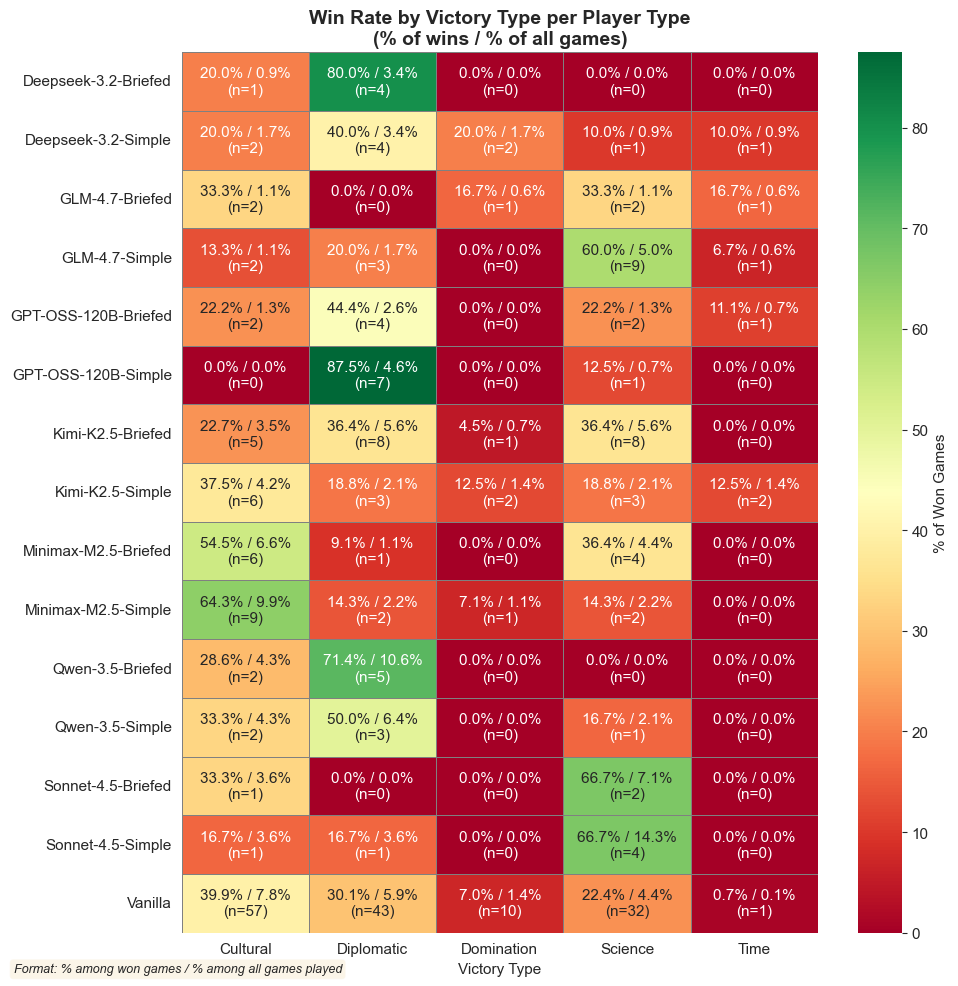


Total wins by player type:
  Deepseek-3.2-Briefed: 5/116 games won (4.3%)
  Deepseek-3.2-Simple: 10/116 games won (8.6%)
  GLM-4.7-Briefed: 6/180 games won (3.3%)
  GLM-4.7-Simple: 15/180 games won (8.3%)
  GPT-OSS-120B-Briefed: 9/153 games won (5.9%)
  GPT-OSS-120B-Simple: 8/153 games won (5.2%)
  Kimi-K2.5-Briefed: 22/144 games won (15.3%)
  Kimi-K2.5-Simple: 16/144 games won (11.1%)
  Minimax-M2.5-Briefed: 11/91 games won (12.1%)
  Minimax-M2.5-Simple: 14/91 games won (15.4%)
  Qwen-3.5-Briefed: 7/47 games won (14.9%)
  Qwen-3.5-Simple: 6/47 games won (12.8%)
  Sonnet-4.5-Briefed: 3/28 games won (10.7%)
  Sonnet-4.5-Simple: 6/28 games won (21.4%)
  Vanilla: 143/730 games won (19.6%)


In [87]:
import seaborn as sns

victory_types = sorted(df['victory_type'].dropna().unique())
player_types = sorted(df['player_type'].unique())

# For each player type: % of wins that are this victory type, and % of all games won by this type
win_pct_data = []   # % among won games (row sums to 100%)
all_pct_data = []   # % among all games played
count_data = []     # number of wins of this type

for pt in player_types:
    pt_df = df[df['player_type'] == pt]
    wins_df = pt_df[pt_df['is_winner'] == 1]
    n_total = len(pt_df)
    n_wins = len(wins_df)

    win_row, all_row, count_row = {}, {}, {}
    for vt in victory_types:
        n_vt_wins = len(wins_df[wins_df['victory_type'] == vt])
        count_row[vt] = n_vt_wins
        win_row[vt] = (n_vt_wins / n_wins * 100) if n_wins > 0 else 0.0
        all_row[vt] = (n_vt_wins / n_total * 100) if n_total > 0 else 0.0

    win_pct_data.append(win_row)
    all_pct_data.append(all_row)
    count_data.append(count_row)

win_pct_df = pd.DataFrame(win_pct_data, index=player_types)
all_pct_df = pd.DataFrame(all_pct_data, index=player_types)
count_matrix = pd.DataFrame(count_data, index=player_types)

# Build annotation: "win%  /  all%\n(n=count)"
annot_array = np.empty(win_pct_df.shape, dtype=object)
for i in range(win_pct_df.shape[0]):
    for j in range(win_pct_df.shape[1]):
        wp = win_pct_df.iloc[i, j]
        ap = all_pct_df.iloc[i, j]
        n = count_matrix.iloc[i, j]
        annot_array[i, j] = f'{wp:.1f}% / {ap:.1f}%\n(n={int(n)})'

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    win_pct_df, annot=annot_array, fmt='', center=None,
    cmap='RdYlGn', vmin=0,
    linewidths=0.5, linecolor='gray', ax=ax,
    cbar_kws={'label': '% of Won Games'}
)
ax.set_title('Win Rate by Victory Type per Player Type\n(% of wins / % of all games)', fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('Victory Type')
plt.xticks(rotation=0)

fig.text(0.02, 0.02, 'Format: % among won games / % among all games played',
         fontsize=9, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

# Print overall win counts per player type
print('\nTotal wins by player type:')
for pt in player_types:
    n_wins = int(count_matrix.loc[pt].sum())
    n_total = len(df[df['player_type'] == pt])
    print(f'  {pt}: {n_wins}/{n_total} games won ({n_wins/n_total*100:.1f}%)')

## Strategy Ratio vs Strength (OLS)

In [ ]:
import seaborn as sns
from statsmodels.formula.api import ols

strategy_cols = ['domination_ratio', 'culture_ratio', 'diplomatic_ratio', 'science_ratio']
strategy_labels = ['Domination', 'Culture', 'Diplomatic', 'Science']

# Create binary variable for dominant strategy (highest ratio)
df['dominant_strategy'] = df[strategy_cols].idxmax(axis=1).str.replace('_ratio', '')

# One-hot encode (drop science as reference to avoid multicollinearity)
for col, label in zip(strategy_cols, strategy_labels):
    key = col.replace('_ratio', '')
    df[f'is_{key}'] = (df['dominant_strategy'] == key).astype(int)

binary_cols = ['is_domination', 'is_culture', 'is_diplomatic']  # science = reference
all_binary = ['is_domination', 'is_culture', 'is_diplomatic', 'is_science']

player_types = sorted(df['player_type'].unique())
coef_data = []
pval_data = []
count_data = []
pct_data = []

for pt in player_types:
    subset = df[df['player_type'] == pt][all_binary + ['adjusted_strength']].dropna()
    n = len(subset)
    if n >= 5:
        # Check we have at least 2 categories present
        n_cats = sum(subset[c].sum() > 0 for c in all_binary)
        if n_cats < 2:
            print(f"Skipping {pt}: only 1 dominant strategy category present")
            coef_row = {label: np.nan for label in strategy_labels}
            pval_row = {label: np.nan for label in strategy_labels}
        else:
            formula = 'adjusted_strength ~ ' + ' + '.join(binary_cols)
            model = ols(formula, data=subset).fit()

            coef_row = {}
            pval_row = {}
            for col, label in zip(all_binary, strategy_labels):
                if col in binary_cols:
                    coef_row[label] = model.params[col]
                    pval_row[label] = model.pvalues[col]
                else:
                    # Science is the reference — derive via sum-to-zero
                    derived_coef = -sum(model.params[c] for c in binary_cols)
                    coef_row[label] = derived_coef
                    vcov = model.cov_params().loc[binary_cols, binary_cols]
                    se_derived = np.sqrt(vcov.values.sum())
                    t_stat = derived_coef / se_derived if se_derived > 0 else 0
                    from scipy import stats as scipy_stats
                    pval_row[label] = 2 * scipy_stats.t.sf(abs(t_stat), df=model.df_resid)

            # Count of games with each dominant strategy
            count_row = {label: int(subset[col].sum()) for col, label in zip(all_binary, strategy_labels)}

            print("=" * 60)
            print(f"OLS for {pt}  (n={n})")
            print("=" * 60)
            print(model.summary())
            print(f"\nDerived Science coef: {coef_row['Science']:.4f} (p={pval_row['Science']:.4f})")
            print(f"Dominant strategy counts: {count_row}")
            print()
    else:
        coef_row = {label: np.nan for label in strategy_labels}
        pval_row = {label: np.nan for label in strategy_labels}
        print(f"Skipping {pt}: n={n} < 5")

    count_row = {label: int(subset[col].sum()) for col, label in zip(all_binary, strategy_labels)}
    pct_row = {label: (count_row[label] / n * 100) if n > 0 else 0 for label in strategy_labels}
    coef_data.append(coef_row)
    pval_data.append(pval_row)
    count_data.append(count_row)
    pct_data.append(pct_row)

coef_df = pd.DataFrame(coef_data, index=player_types)
pval_df = pd.DataFrame(pval_data, index=player_types)
count_df = pd.DataFrame(count_data, index=player_types)
pct_df = pd.DataFrame(pct_data, index=player_types)

def pvalue_to_stars(p):
    if np.isnan(p):
        return ''
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return ''

annot_array = np.empty(coef_df.shape, dtype=object)
for i in range(coef_df.shape[0]):
    for j in range(coef_df.shape[1]):
        b = coef_df.iloc[i, j]
        p = pval_df.iloc[i, j]
        n = count_df.iloc[i, j]
        pct = pct_df.iloc[i, j]
        if np.isnan(b):
            annot_array[i, j] = ''
        else:
            stars = pvalue_to_stars(p)
            annot_array[i, j] = f'{b:.2f}{stars}\n({int(n)}, {pct:.0f}%)'

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    coef_df, annot=annot_array, fmt='', center=0,
    cmap='RdYlGn', vmin=-1, vmax=1,
    linewidths=0.5, linecolor='gray', ax=ax,
    cbar_kws={'label': 'OLS β (sum-to-zero)'}
)
ax.set_title('Dominant Strategy vs Civ-Adjusted Strength\n(OLS β, sum-to-zero constraint, by Player Type)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('')

plt.tight_layout()
fig.subplots_adjust(bottom=0.08)
fig.text(0.02, 0.01,
         'Significance: * p<0.05, ** p<0.01, *** p<0.001 | Science = reference, derived via sum-to-zero | (n games, % of player games)',
         fontsize=9, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.show()

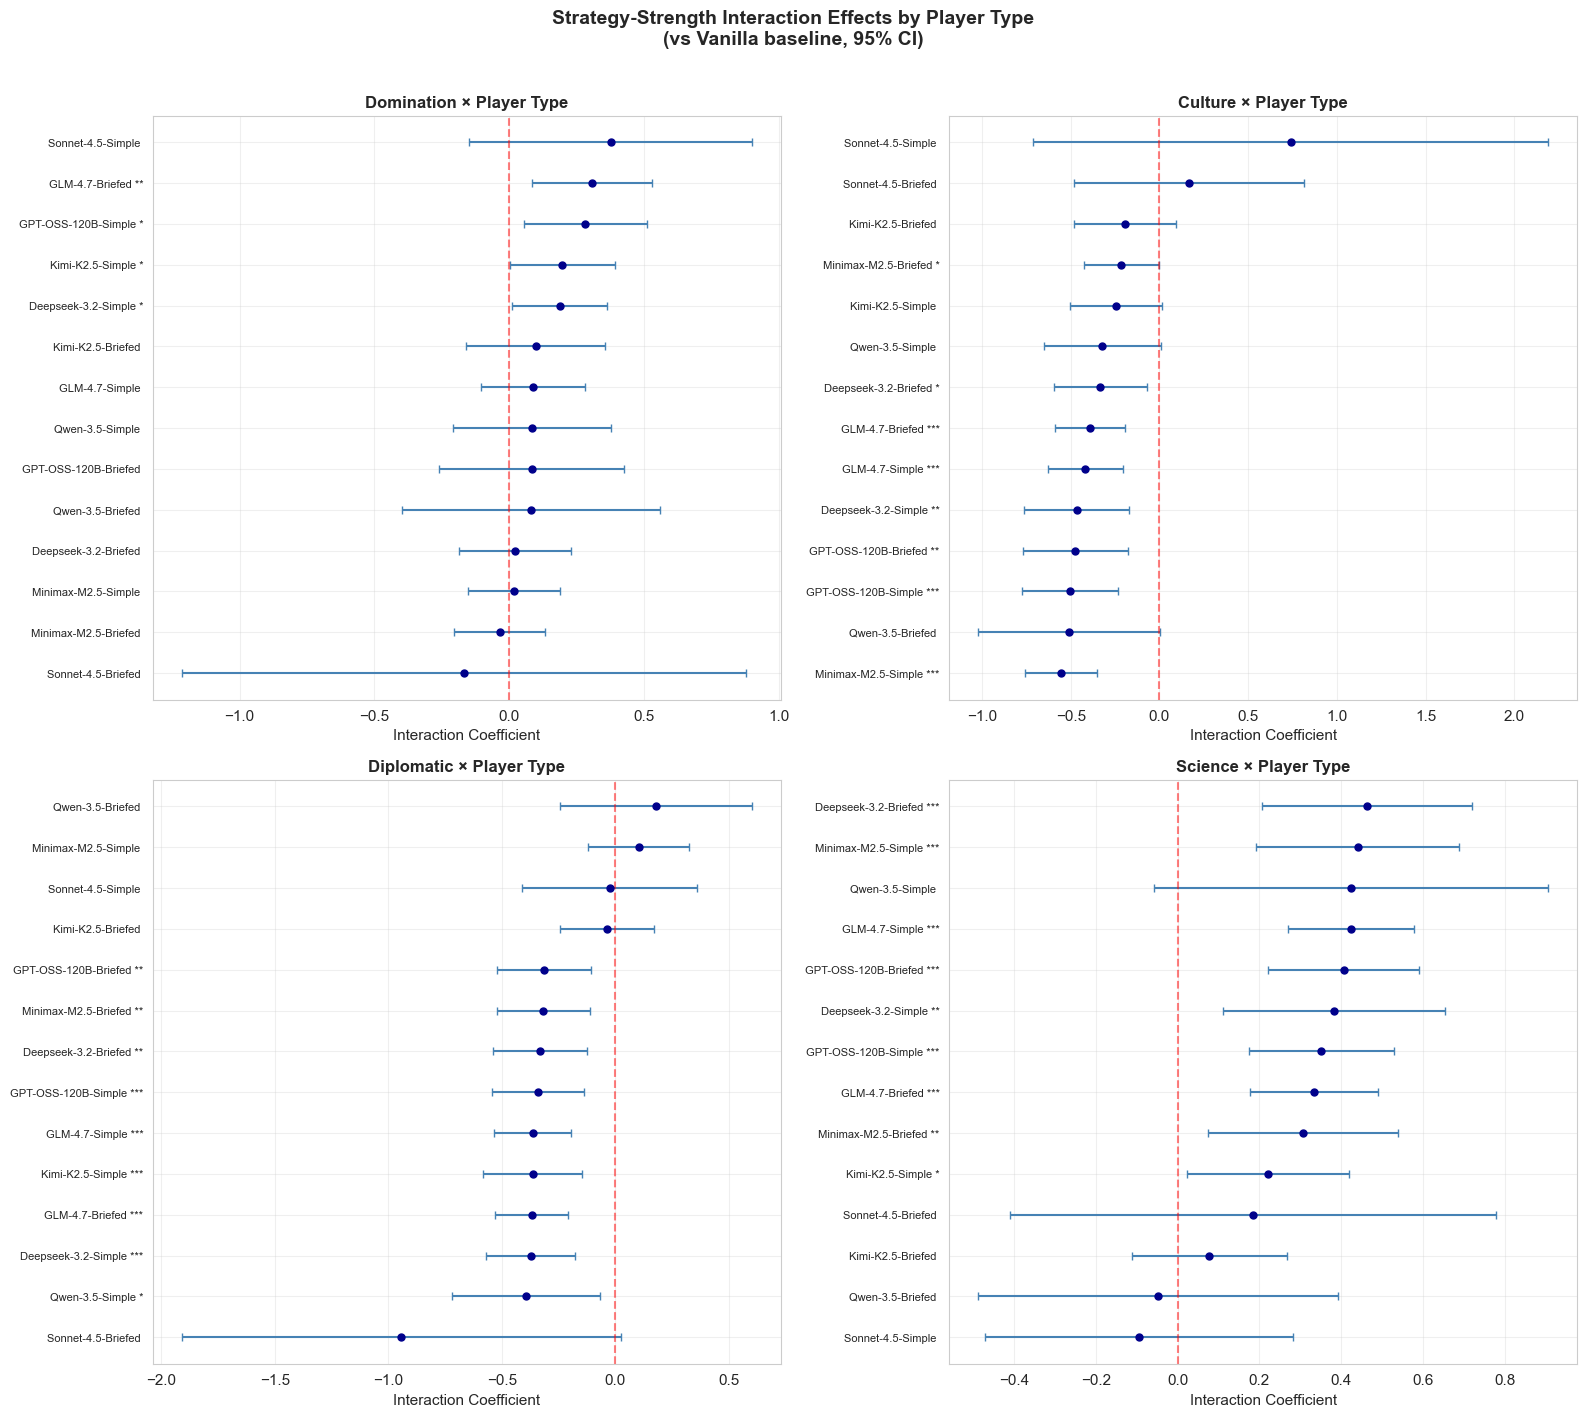

In [89]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from plot_utilities import plot_forest_plot, prepare_coefficient_data

# For each strategy, run interaction regression: strength ~ ratio * player_type
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for idx, (col, label) in enumerate(zip(strategy_cols, strategy_labels)):
    ax = axes[idx // 2, idx % 2]

    analysis_df = df[[col, 'adjusted_strength', 'player_type']].dropna()

    formula = f'adjusted_strength ~ {col} * C(player_type, Treatment(reference="Vanilla"))'
    model = ols(formula, data=analysis_df).fit()

    # Extract interaction coefficients
    interaction_vars = [v for v in model.params.index if ':' in v and col in v]

    if interaction_vars:
        coef_df = prepare_coefficient_data(
            model.params, model.conf_int(), model.pvalues,
            interaction_vars, var_type='condition'
        )

        # Plot on subplot using correct column names from prepare_coefficient_data
        ax.errorbar(
            coef_df['Effect'], range(len(coef_df)),
            xerr=[coef_df['Effect'] - coef_df['CI_Low'],
                  coef_df['CI_High'] - coef_df['Effect']],
            fmt='o', color='darkblue', ecolor='steelblue', capsize=3, markersize=5
        )
        ax.set_yticks(range(len(coef_df)))
        ax.set_yticklabels([f'{name} {sig}' for name, sig in zip(coef_df['Name'], coef_df['Sig'])], fontsize=8)
        ax.axvline(0, color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel('Interaction Coefficient')

    ax.set_title(f'{label} × Player Type', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

fig.suptitle('Strategy-Strength Interaction Effects by Player Type\n(vs Vanilla baseline, 95% CI)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

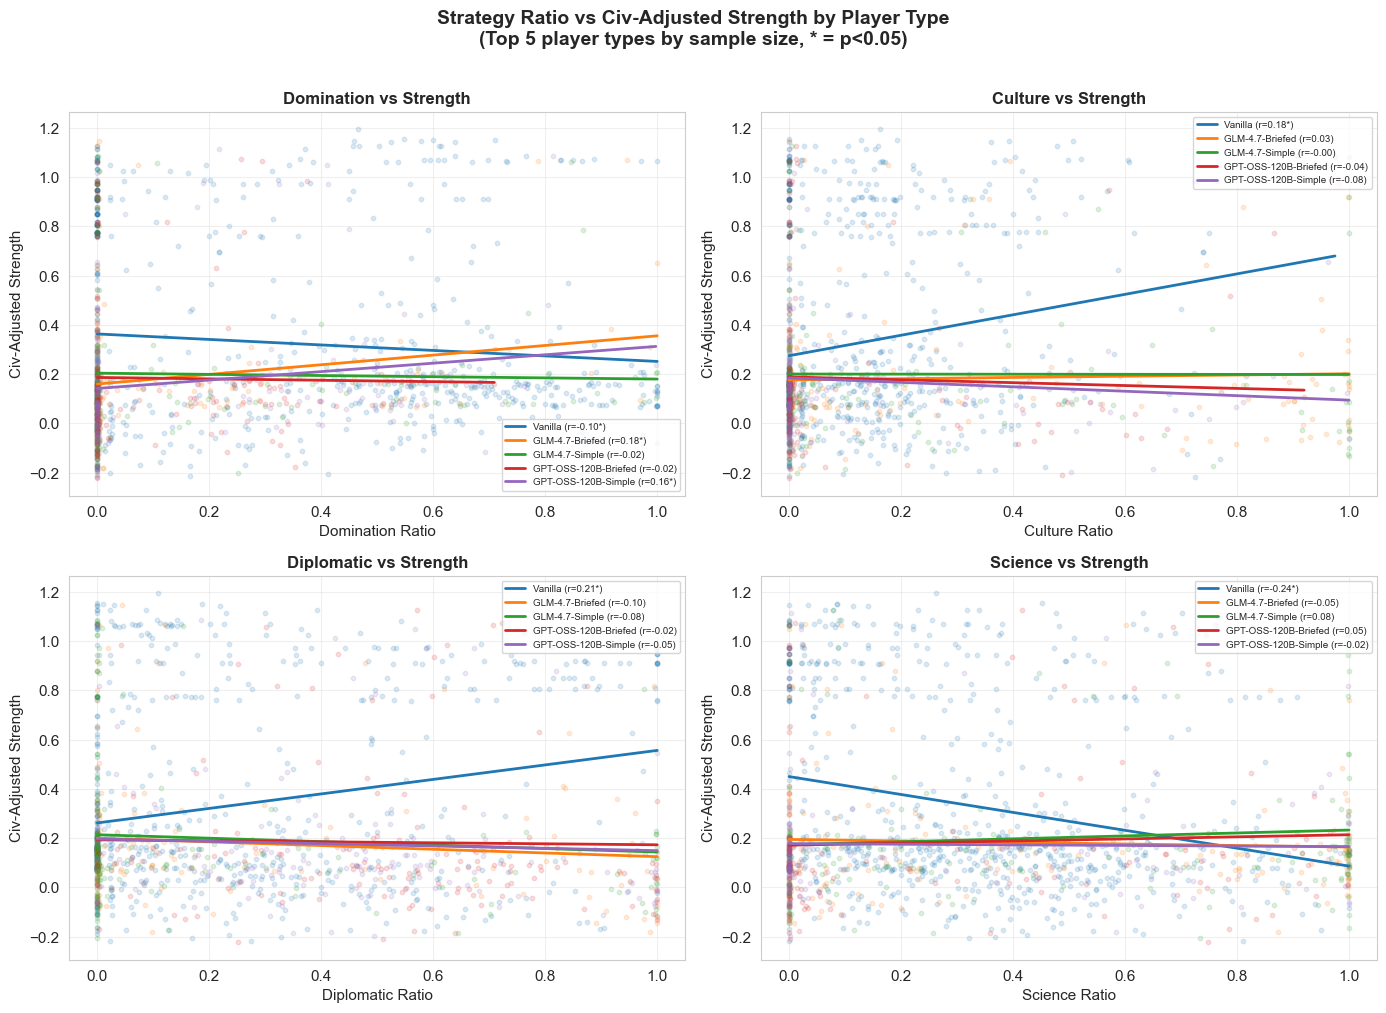

In [90]:
# Scatter plots: strategy ratio vs adjusted_strength with per-player-type regression lines
# Show top 5 player types by game count for readability

top_types = df['player_type'].value_counts().head(5).index.tolist()
plot_df = df[df['player_type'].isin(top_types)].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (col, label) in enumerate(zip(strategy_cols, strategy_labels)):
    ax = axes[idx // 2, idx % 2]

    for pt in top_types:
        subset = plot_df[plot_df['player_type'] == pt][[col, 'adjusted_strength']].dropna()
        if len(subset) < 5:
            continue
        ax.scatter(subset[col], subset['adjusted_strength'], alpha=0.15, s=10)

        # Regression line
        slope, intercept, r, p, se = stats.linregress(subset[col], subset['adjusted_strength'])
        x_line = np.linspace(subset[col].min(), subset[col].max(), 50)
        sig = '*' if p < 0.05 else ''
        ax.plot(x_line, intercept + slope * x_line, linewidth=2,
                label=f'{pt} (r={r:.2f}{sig})')

    ax.set_xlabel(f'{label} Ratio')
    ax.set_ylabel('Civ-Adjusted Strength')
    ax.set_title(f'{label} vs Strength', fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)

fig.suptitle('Strategy Ratio vs Civ-Adjusted Strength by Player Type\n(Top 5 player types by sample size, * = p<0.05)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()